# Lab — Statistical Testing with SciPy (Starter)

**Estimated time:** ~30 minutes  
**Tools:** Python 3, Jupyter Notebook, SciPy, Pandas, NumPy, Matplotlib

You will:
- Compute **descriptive statistics**
- Define a **hypothesis** (H₀ / H₁)
- Run a **hypothesis test** with SciPy
- **Visualise** distributions to support interpretation
- Summarise conclusions in **markdown**


## 1) Setup & Environment Check

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import scipy
    from scipy import stats
    print("SciPy version:", scipy.__version__)
except ImportError:
    raise ImportError(
        "SciPy is not installed. Install it with:\n"
        "  - pip install scipy\n"
        "  - conda install scipy"
    )


SciPy version: 1.16.3


## 2) Load the Dataset

In [2]:
from pathlib import Path  

In [6]:
# TODO: Load dataset
# df = pd.read_csv("data/raw/experiment_results.csv")

#RAW = Path("..") / "data" / "raw" 
#PROCESSED = Path("..") / ("data") / "processed"
# i was so sused to getting teh raw data i forgot to actually manually check the folders so see what is actually in the csv data fikle i was reading 
#df= pd.read_csv((RAW_PATH / /experiment_results.csv" ))
df= pd.read_csv(Path("..") / "data" / "experiment_results.csv" )

# YOUR CODE HERE
df.head()

,participant_id,group,time_on_task_seconds
0,C001,control,323.7
1,C002,control,263.2
2,C003,control,343.8
3,C004,control,352.3
4,C005,control,222.2


In [9]:
# TODO: Preview + basic checks
#df.head()
df.info()
df.describe()

# YOUR CODE HERE


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   participant_id        120 non-null    object 
 1   group                 120 non-null    object 
 2   time_on_task_seconds  120 non-null    float64
dtypes: float64(1), object(2)
memory usage: 2.9+ KB


,time_on_task_seconds
count,120.000000
mean,317.285000
std,35.131957
min,222.200000
25%,290.350000
50%,317.650000
75%,343.500000
max,406.400000


## 3) Compute Descriptive Statistics

In [14]:
# TODO: Overall descriptive stats
df["time_on_task_seconds"].describe()
df["time_on_task_seconds"].info()
df["group"].value_counts()
# YOUR CODE HERE


<class 'pandas.core.series.Series'>
RangeIndex: 120 entries, 0 to 119
Series name: time_on_task_seconds
Non-Null Count  Dtype  
--------------  -----  
120 non-null    float64
dtypes: float64(1)
memory usage: 1.1 KB


group
control      60
treatment    60
Name: count, dtype: int64

In [15]:
# TODO: Grouped descriptive stats
df.groupby("group")["time_on_task_seconds"].agg(["count", "mean", "std", "min", "max"])

# YOUR CODE HERE


,count,mean,std,min,max
group,,,,,
control,60,312.938333,35.354745,222.2,406.4
treatment,60,321.631667,34.656066,252.3,402.1


## 4) Define Your Hypothesis

### Hypothesis

- **H₀ (null):**  
- **H₁ (alternative):**  
- **Significance level (α):** 0.05




h(0) null hypothesis is That there is no signficnat chhange in the time_on_task_seconds between teh control and treatment group 
h(1) alnertaive is that there is a signficant change inteh time on task between teh contriol and treatment group  
with a confidence interval of 0.05 

## 5) Perform a Hypothesis Test (SciPy)

In [18]:
# TODO: Split into two arrays
#in these statements with take all the outputs that are control and traetment and convert them to an arraay speficisally 
control = df.loc[df["group"] == "control", "time_on_task_seconds"].to_numpy()
treatment = df.loc[df["group"] == "treatment", "time_on_task_seconds"].to_numpy()

# YOUR CODE HERE
#




In [32]:
# TODO: Run Welch's t-test (recommended when variances may differ)
t_stat, p_value = stats.ttest_ind(treatment, control, equal_var=False)
print("t statistic:", t_stat)
print("p-value:", p_value)

# checking if our p value is less the teh conficdence interval of .05 aka alpha menas basically how likely has this data changed and made a signficant difference from treatment to control but also we need to look at other things too to make sure this tells teh same story 

alpha = 0.05
if p_value < alpha:
    print(" There is a signficant difference between teh controla nd treatment")
else:
    print("There is no signficant difference between control and treatment groups")


t statistic: -1.3601607062059062
p-value: 0.17637296469048666
There is no signficant difference between control and treatment groups


In [20]:
df.columns.tolist()

['participant_id', 'group', 'time_on_task_seconds']

## 6) Visualise the Data

Text(0.5, 1.0, 'Control Vs Treatment')

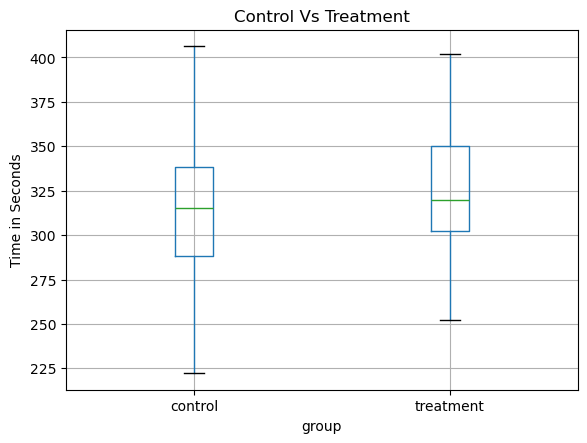

In [25]:
# TODO: Create at least ONE plot (boxplot or histogram) to compare groups.
# Tip: A boxplot is often a quick, clear comparison.

ax = df.boxplot(column="time_on_task_seconds",by="group")

ax.set_ylabel("Time in Seconds")
plt.suptitle("")
plt.title("Control Vs Treatment")

# YOUR CODE HERE

# too many labels here would make teh box plot chart hard to read right now the viewer can clearly tell that these to charts look very similar rto eachother 

## 7) Interpret and Document Results

### Results & Interpretation

- **Test used:**  
- **t statistic:**  
- **p-value:**  
- **Decision (α = 0.05):**  
- **Plain-language conclusion:**  

**Assumptions / limitations:**  
-  


In [31]:
print(f"Group Control Mean: {np.mean(control):.2f} (Std: {np.std(control):.2f})")
print(f"Group treatment Mean: {np.mean(treatment):.2f} (Std: {np.std(treatment):.2f})")
print(f" the t-stat is {np.mean(t_stat):.2f} and the p-value is:{np.mean(p_value):.2f}")

Group Control Mean: 312.94 (Std: 35.06)
Group treatment Mean: 321.63 (Std: 34.37)
 the t-stat is -1.36 and the p-value is:0.18


In [ ]:
# I made a box plot thaty grouped the treatment and control as you can see here the there is no biig difference between them the only thing is that the treatment data seems to have less outliers in teh lower range and the treatment has a little less outliers at the top
# The ojnly real difference between the teh treatment and control is that contol has a lower min and a higher max than treatment but the means are very similar rto eachother 
# with the ttest and p value it confirms that there is no real differenc between these 2 values meaning the that we can accept the null hypothesis h(0) 